In [ ]:
import sys
import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, accuracy_score, log_loss

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

In [ ]:
# Конфигурация
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "bigdata" / "processed"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "exp2_statistical_ts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
MIN_TRAIN_OBS = 200          # минимальное число наблюдений для обучения
TEST_START = '2023-01-01'    # начало теста
TOP_N_TICKERS = 10           # количество тикеров для анализа
np.random.seed(RANDOM_SEED)

In [ ]:
# Загрузка данных
df = pd.read_parquet(PROCESSED_DIR / "combined_features.parquet")

# Отбираем топ-N тикеров по среднему объёму (аналогично exp1)
ticker_counts = df['ticker'].value_counts()
top_tickers = ticker_counts.head(TOP_N_TICKERS).index.tolist()
logger.info(f"Выбраны тикеры: {top_tickers}")

# Подготовка ряда для одного тикера
def prepare_series(ticker, df):
    """
    Возвращает DataFrame с датой, лог-доходностью (однодневной) 
    и бинарным таргетом (знак доходности следующего дня).
    """
    d = df[df['ticker'] == ticker].copy().sort_values('date')
    d['log_ret'] = np.log(d['close'] / d['close'].shift(1))
    d['target_binary'] = (d['log_ret'].shift(-1) > 0).astype(int)
    d = d.dropna(subset=['log_ret', 'target_binary'])
    return d[['date', 'log_ret', 'target_binary']]

2026-05-22 22:09:27,152 [INFO] Выбраны тикеры: ['LKOH', 'SNGS', 'SNGSP', 'MSNG', 'RTKM', 'SBER', 'SBERP', 'RTKMP', 'AFLT', 'SIBN']


In [ ]:
# Функции для расширяющегося прогноза
def rolling_forecast_arima(y_train, y_test):
    """
    Прогноз ARIMA(1,0,1) с расширяющимся окном.
    Возвращает массив прогнозов на каждый шаг тестового периода.
    """
    forecasts = []
    history = list(y_train)
    for t in range(len(y_test)):
        try:
            model = ARIMA(history, order=(1,0,1))
            fit = model.fit()
            pred = fit.forecast()[0]
        except Exception as e:
            logger.debug(f"Ошибка ARIMA на шаге {t}: {e}")
            pred = 0.0
        forecasts.append(pred)
        history.append(y_test.iloc[t])
    return np.array(forecasts)

def rolling_forecast_garch(y_train, y_test):
    """
    Прогноз GARCH(1,1) с AR(1) средним, расширяющееся окно.
    При ошибке или несходимости использует последнее наблюдение.
    """
    forecasts = []
    history = list(y_train)
    for t in range(len(y_test)):
        try:
            model = arch_model(history, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal')
            res = model.fit(update_freq=5, disp='off', show_warning=False)
            if res.converged:
                pred = res.forecast(horizon=1).mean.iloc[-1, 0]
            else:
                pred = history[-1]
        except Exception:
            pred = history[-1]
        forecasts.append(pred)
        history.append(y_test.iloc[t])
    return np.array(forecasts)

In [ ]:
# Основной цикл по тикерам
results = []

for ticker in top_tickers:
    logger.info(f"\n=== Обработка {ticker} ===")
    series = prepare_series(ticker, df)
    
    # Разделение на train / test по датам
    train = series[series['date'] < TEST_START]
    test = series[series['date'] >= TEST_START]
    
    if len(train) < MIN_TRAIN_OBS or len(test) < 10:
        logger.warning(f"Недостаточно данных: train={len(train)}, test={len(test)}")
        continue
    
    y_train = train['log_ret']
    y_test = test['log_ret']
    binary_train = train['target_binary']
    binary_test = test['target_binary']
    
    # ARIMA
    try:
        pred_arima = rolling_forecast_arima(y_train, y_test)
        rmse_arima = np.sqrt(mean_squared_error(y_test, pred_arima))
        mae_arima = mean_absolute_error(y_test, pred_arima)
        r2_arima = r2_score(y_test, pred_arima)
        
        pred_bin_arima = (pred_arima > 0).astype(int)
        acc_arima = accuracy_score(binary_test, pred_bin_arima)
        if len(np.unique(binary_test)) > 1:
            auc_arima = roc_auc_score(binary_test, pred_arima)
        else:
            auc_arima = 0.5
            logger.warning(f"  AUC для {ticker} ARIMA не определён (один класс в тесте)")
        
        results.append({
            'ticker': ticker, 'model': 'ARIMA',
            'rmse': rmse_arima, 'mae': mae_arima, 'r2': r2_arima,
            'accuracy': acc_arima, 'auc': auc_arima
        })
        logger.info(f"  ARIMA: RMSE={rmse_arima:.4f}, AUC={auc_arima:.4f}")
    except Exception as e:
        logger.error(f"  ARIMA ошибка: {e}")
    
    # GARCH
    try:
        pred_garch = rolling_forecast_garch(y_train, y_test)
        rmse_garch = np.sqrt(mean_squared_error(y_test, pred_garch))
        mae_garch = mean_absolute_error(y_test, pred_garch)
        r2_garch = r2_score(y_test, pred_garch)
        
        pred_bin_garch = (pred_garch > 0).astype(int)
        acc_garch = accuracy_score(binary_test, pred_bin_garch)
        if len(np.unique(binary_test)) > 1:
            auc_garch = roc_auc_score(binary_test, pred_garch)
        else:
            auc_garch = 0.5
            logger.warning(f"  AUC для {ticker} GARCH не определён (один класс в тесте)")
        
        results.append({
            'ticker': ticker, 'model': 'GARCH',
            'rmse': rmse_garch, 'mae': mae_garch, 'r2': r2_garch,
            'accuracy': acc_garch, 'auc': auc_garch
        })
        logger.info(f"  GARCH: RMSE={rmse_garch:.4f}, AUC={auc_garch:.4f}")
    except Exception as e:
        logger.error(f"  GARCH ошибка: {e}")

2026-05-22 22:16:02,848 [INFO] 
=== Обработка LKOH ===
2026-05-22 22:21:51,182 [INFO]   ARIMA: RMSE=0.0136, AUC=0.4685
2026-05-22 22:22:09,542 [INFO]   GARCH: RMSE=0.0191, AUC=0.5269
2026-05-22 22:22:09,543 [INFO] 
=== Обработка SNGS ===
2026-05-22 22:23:30,785 [INFO]   ARIMA: RMSE=0.0184, AUC=0.4775
2026-05-22 22:23:42,207 [INFO]   GARCH: RMSE=0.0253, AUC=0.4707
2026-05-22 22:23:42,207 [INFO] 
=== Обработка SNGSP ===
2026-05-22 22:25:14,173 [INFO]   ARIMA: RMSE=0.0212, AUC=0.4649
2026-05-22 22:25:22,915 [INFO]   GARCH: RMSE=0.0294, AUC=0.4703
2026-05-22 22:25:22,915 [INFO] 
=== Обработка MSNG ===
2026-05-22 22:29:27,947 [INFO]   ARIMA: RMSE=0.0225, AUC=0.5765
2026-05-22 22:29:47,301 [INFO]   GARCH: RMSE=0.0321, AUC=0.4146
2026-05-22 22:29:47,302 [INFO] 
=== Обработка RTKM ===
2026-05-22 22:33:55,246 [INFO]   ARIMA: RMSE=0.0179, AUC=0.5131
2026-05-22 22:34:10,405 [INFO]   GARCH: RMSE=0.0259, AUC=0.4928
2026-05-22 22:34:10,405 [INFO] 
=== Обработка SBER ===
2026-05-22 22:38:00,220 [INFO

2026-05-22 23:04:21,031 [INFO] 
=== Итоги по статистическим моделям ===
2026-05-22 23:04:21,036 [INFO]    model      rmse       mae        r2  accuracy      auc
0  ARIMA  0.018047  0.012504 -0.122931  0.506905  0.49937
1  GARCH  0.023974  0.017203 -0.963824  0.495000  0.48570


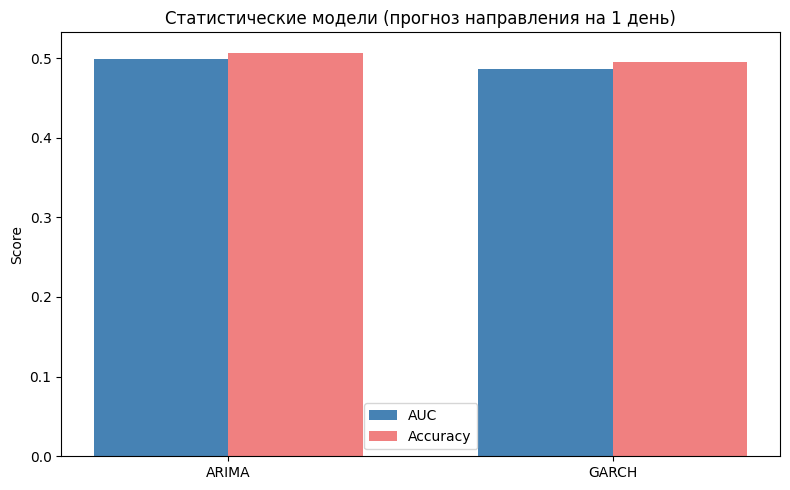

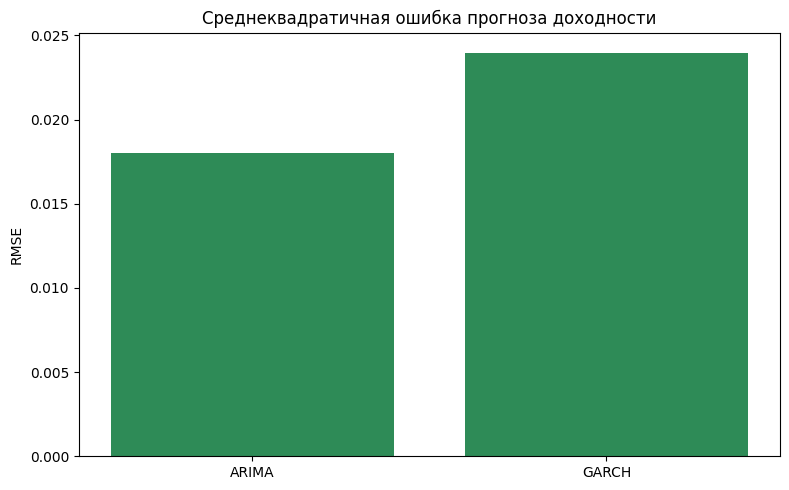

2026-05-22 23:04:21,402 [INFO] Эксперимент 2 завершён. Результаты сохранены в artifacts/exp2_statistical_ts


In [ ]:
# Агрегация и сохранение
if results:
    # Средние метрики по моделям
    summary = pd.DataFrame(results).groupby('model').agg({
        'rmse': 'mean', 'mae': 'mean', 'r2': 'mean',
        'accuracy': 'mean', 'auc': 'mean'
    }).reset_index()
    
    logger.info("\n=== Итоги по статистическим моделям ===")
    logger.info(summary.to_string())
    
    # Сохранение в файлы
    summary.to_csv(ARTIFACTS_DIR / 'statistical_models_summary.csv', index=False)
    pd.DataFrame(results).to_csv(ARTIFACTS_DIR / 'statistical_models_per_ticker.csv', index=False)
    
    # Сохранение JSON (как в exp1)
    with open(ARTIFACTS_DIR / 'results.json', 'w') as f:
        json.dump(results, f, indent=2, default=str)
    
    # График сравнения AUC и Accuracy
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(summary))
    width = 0.35
    ax.bar(x - width/2, summary['auc'], width, label='AUC', color='steelblue')
    ax.bar(x + width/2, summary['accuracy'], width, label='Accuracy', color='lightcoral')
    ax.set_xticks(x)
    ax.set_xticklabels(summary['model'])
    ax.set_ylabel('Score')
    ax.set_title('Статистические модели (прогноз направления на 1 день)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'statistical_models.png', dpi=150)
    plt.show()
    
    # Дополнительный график RMSE
    plt.figure(figsize=(8, 5))
    plt.bar(summary['model'], summary['rmse'], color='seagreen')
    plt.ylabel('RMSE')
    plt.title('Среднеквадратичная ошибка прогноза доходности')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'statistical_models_rmse.png', dpi=150)
    plt.show()
else:
    logger.warning("Нет результатов для отображения")

logger.info("Эксперимент 2 завершён. Результаты сохранены в artifacts/exp2_statistical_ts")

In [ ]:
# прогноз на 20 дней (рекурсивный)
HORIZON = 20

# Подготовка данных
def prepare_cumulative_series(ticker, df, horizon=HORIZON):
    """
    Возвращает DataFrame с датой, однодневной лог-доходностью и
    накопленной лог-доходностью за horizon дней (target).
    """
    d = df[df['ticker'] == ticker].copy().sort_values('date')
    d['log_ret_1d'] = np.log(d['close'] / d['close'].shift(1))
    d['target_cumulative'] = np.log(d['close'].shift(-horizon) / d['close'])
    # Бинарный таргет: знак накопленной доходности
    d['target_binary_cumulative'] = (d['target_cumulative'] > 0).astype(int)
    d = d.dropna(subset=['log_ret_1d', 'target_cumulative', 'target_binary_cumulative'])
    return d[['date', 'log_ret_1d', 'target_cumulative', 'target_binary_cumulative']]

# Рекурсивный прогноз ARIMA на horizon шагов
def recursive_forecast_arima(history, steps=HORIZON):
    """
    Рекурсивный прогноз ARIMA(1,0,1) на steps шагов вперёд.
    На каждом шаге модель переобучается, а прогноз используется как следующее значение.
    Возвращает массив прогнозов однодневной доходности (длина steps).
    """
    preds = []
    current_history = list(history)
    for _ in range(steps):
        try:
            model = ARIMA(current_history, order=(1,0,1))
            fit = model.fit()
            pred = fit.forecast()[0]
        except Exception:
            pred = 0.0
        preds.append(pred)
        current_history.append(pred)   # используем прогноз для следующего шага
    return np.array(preds)

# Рекурсивный прогноз GARCH на horizon шагов
def recursive_forecast_garch(history, steps=HORIZON):
    """
    Рекурсивный прогноз GARCH(1,1)+AR(1) на steps шагов вперёд.
    """
    preds = []
    current_history = list(history)
    for _ in range(steps):
        try:
            model = arch_model(current_history, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal')
            res = model.fit(update_freq=5, disp='off', show_warning=False)
            if res.converged:
                pred = res.forecast(horizon=1).mean.iloc[-1, 0]
            else:
                pred = current_history[-1] if current_history else 0.0
        except Exception:
            pred = current_history[-1] if current_history else 0.0
        preds.append(pred)
        current_history.append(pred)
    return np.array(preds)

In [ ]:
# Основной цикл для горизонта 20
results_horizon = []

SKIP_STEPS = 20

for ticker in top_tickers:
    logger.info(f"\n=== Обработка {ticker} (горизонт {HORIZON} дней) ===")
    series = prepare_cumulative_series(ticker, df, horizon=HORIZON)
    
    train = series[series['date'] < TEST_START]
    test = series[series['date'] >= TEST_START]
    
    if len(train) < MIN_TRAIN_OBS or len(test) < HORIZON + 1:
        logger.warning(f"Недостаточно данных: train={len(train)}, test={len(test)}")
        continue
    
    # Прогноз делаем в день t, предсказываем накопленную доходность за [t+1, t+HORIZON]
    test_indices = list(range(0, len(test) - HORIZON + 1, SKIP_STEPS))
    
    actual_cumulative = []
    pred_cumulative_arima = []
    pred_cumulative_garch = []
    
    # История однодневных доходностей: все train + предыдущие фактические тестовые значения
    history_1d = list(train['log_ret_1d'])
    
    for i in test_indices:
        # Берем историю до текущего момента (включая фактические данные теста до i)
        # Для i=0 история = все train. Для i>0 добавляем фактические доходности test[0:i]
        if i > 0:
            # Добавляем фактические однодневные доходности, которые уже известны
            actual_1d = test['log_ret_1d'].iloc[:i].tolist()
            current_history = history_1d + actual_1d
        else:
            current_history = history_1d.copy()
        
        # Рекурсивный прогноз на HORIZON шагов (однодневные доходности)
        pred_1d_arima = recursive_forecast_arima(current_history, steps=HORIZON)
        pred_1d_garch = recursive_forecast_garch(current_history, steps=HORIZON)
        
        # Суммируем прогнозы → прогноз накопленной лог-доходности
        pred_cum_arima = np.sum(pred_1d_arima)
        pred_cum_garch = np.sum(pred_1d_garch)
        
        # Фактическая накопленная доходность за этот период
        actual_cum = test['target_cumulative'].iloc[i]  # индекс последнего дня периода
        
        actual_cumulative.append(actual_cum)
        pred_cumulative_arima.append(pred_cum_arima)
        pred_cumulative_garch.append(pred_cum_garch)
        
        # Логирование прогресса (каждые 20 прогнозов)
        if i % (SKIP_STEPS * 20) == 0:
            logger.debug(f"  Прогноз для дня {i} из {len(test)}")
    
    if not actual_cumulative:
        logger.warning(f"Нет прогнозов для {ticker}")
        continue
    
    # Метрики для ARIMA
    pred_arima = np.array(pred_cumulative_arima)
    true = np.array(actual_cumulative)
    rmse_arima = np.sqrt(mean_squared_error(true, pred_arima))
    mae_arima = mean_absolute_error(true, pred_arima)
    r2_arima = r2_score(true, pred_arima)
    pred_bin_arima = (pred_arima > 0).astype(int)
    true_bin = test['target_binary_cumulative'].iloc[test_indices].values
    acc_arima = accuracy_score(true_bin, pred_bin_arima)
    if len(np.unique(true_bin)) > 1:
        auc_arima = roc_auc_score(true_bin, pred_arima)
    else:
        auc_arima = 0.5
    
    results_horizon.append({
        'ticker': ticker, 'model': f'ARIMA_{HORIZON}d_recursive',
        'rmse': rmse_arima, 'mae': mae_arima, 'r2': r2_arima,
        'accuracy': acc_arima, 'auc': auc_arima
    })
    logger.info(f"  ARIMA_{HORIZON}d: RMSE={rmse_arima:.4f}, AUC={auc_arima:.4f}, ACC={acc_arima:.4f}")
    
    # Метрики для GARCH
    pred_garch = np.array(pred_cumulative_garch)
    rmse_garch = np.sqrt(mean_squared_error(true, pred_garch))
    mae_garch = mean_absolute_error(true, pred_garch)
    r2_garch = r2_score(true, pred_garch)
    pred_bin_garch = (pred_garch > 0).astype(int)
    acc_garch = accuracy_score(true_bin, pred_bin_garch)
    if len(np.unique(true_bin)) > 1:
        auc_garch = roc_auc_score(true_bin, pred_garch)
    else:
        auc_garch = 0.5
    
    results_horizon.append({
        'ticker': ticker, 'model': f'GARCH_{HORIZON}d_recursive',
        'rmse': rmse_garch, 'mae': mae_garch, 'r2': r2_garch,
        'accuracy': acc_garch, 'auc': auc_garch
    })
    logger.info(f"  GARCH_{HORIZON}d: RMSE={rmse_garch:.4f}, AUC={auc_garch:.4f}, ACC={acc_garch:.4f}")

2026-05-22 23:12:44,880 [INFO] 
=== Обработка LKOH (горизонт 20 дней) ===
2026-05-22 23:18:36,715 [INFO]   ARIMA_20d: RMSE=0.0667, AUC=0.2637, ACC=0.6500
2026-05-22 23:18:36,717 [INFO]   GARCH_20d: RMSE=0.1973, AUC=0.7912, ACC=0.8000
2026-05-22 23:18:36,717 [INFO] 
=== Обработка SNGS (горизонт 20 дней) ===
2026-05-22 23:20:00,625 [INFO]   ARIMA_20d: RMSE=0.0902, AUC=0.4646, ACC=0.5500
2026-05-22 23:20:00,632 [INFO]   GARCH_20d: RMSE=0.2652, AUC=0.4747, ACC=0.5000
2026-05-22 23:20:00,632 [INFO] 
=== Обработка SNGSP (горизонт 20 дней) ===
2026-05-22 23:21:34,902 [INFO]   ARIMA_20d: RMSE=0.1115, AUC=0.4533, ACC=0.7500
2026-05-22 23:21:34,904 [INFO]   GARCH_20d: RMSE=0.3868, AUC=0.4000, ACC=0.5000
2026-05-22 23:21:34,904 [INFO] 
=== Обработка MSNG (горизонт 20 дней) ===
2026-05-22 23:25:33,446 [INFO]   ARIMA_20d: RMSE=0.0951, AUC=0.1919, ACC=0.5000
2026-05-22 23:25:33,449 [INFO]   GARCH_20d: RMSE=0.3727, AUC=0.5455, ACC=0.5500
2026-05-22 23:25:33,450 [INFO] 
=== Обработка RTKM (горизонт 20

2026-05-22 23:58:23,290 [INFO] 
=== Итоги по статистическим моделям (горизонт 20) ===
2026-05-22 23:58:23,293 [INFO]                  model      rmse       mae         r2  accuracy       auc
0  ARIMA_20d_recursive  0.085001  0.063767  -0.040690      0.62  0.355382
1  GARCH_20d_recursive  0.290709  0.221848 -11.753182      0.58  0.558720


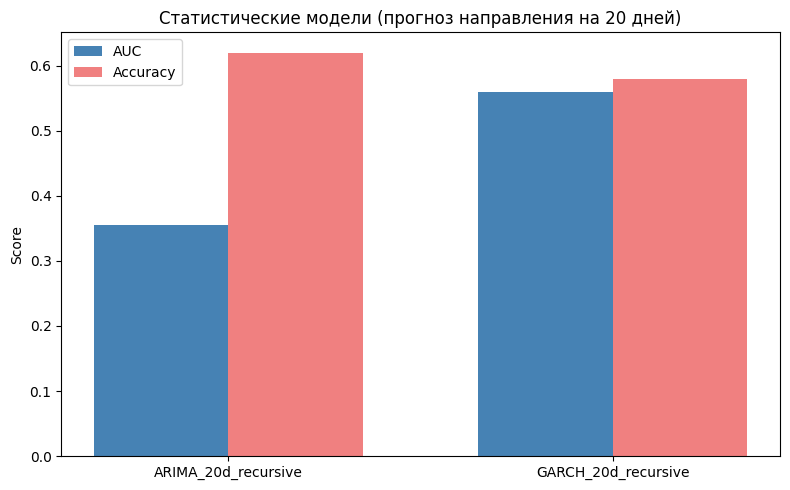

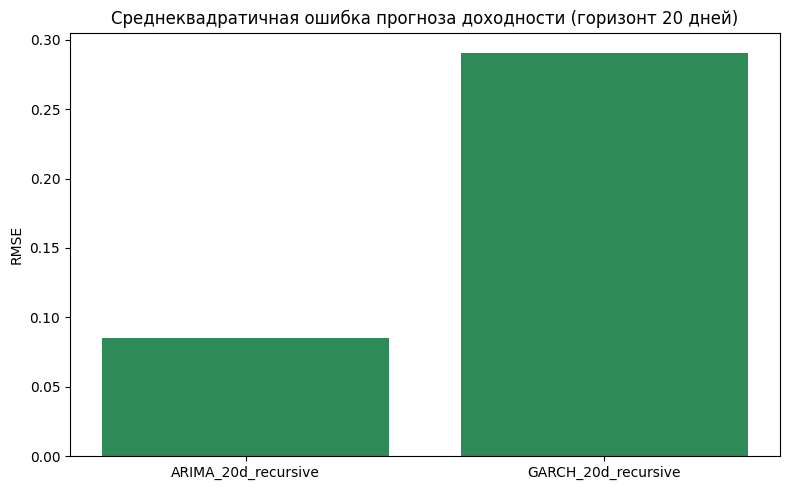

2026-05-22 23:58:23,638 [INFO] Прогноз на 20 дней завершён. Результаты сохранены в d:\Storage\Projects\dpo\dpo\project\artifacts\exp2_statistical_ts


In [10]:
# -------------------- Агрегация результатов для горизонта 20 --------------------
if results_horizon:
    summary_horizon = pd.DataFrame(results_horizon).groupby('model').agg({
        'rmse': 'mean', 'mae': 'mean', 'r2': 'mean',
        'accuracy': 'mean', 'auc': 'mean'
    }).reset_index()
    
    logger.info("\n=== Итоги по статистическим моделям (горизонт 20) ===")
    logger.info(summary_horizon.to_string())
    
    # Сохранение
    summary_horizon.to_csv(ARTIFACTS_DIR / 'statistical_models_summary_horizon20.csv', index=False)
    pd.DataFrame(results_horizon).to_csv(ARTIFACTS_DIR / 'statistical_models_per_ticker_horizon20.csv', index=False)
    
    with open(ARTIFACTS_DIR / 'results_horizon20.json', 'w') as f:
        json.dump(results_horizon, f, indent=2, default=str)
    
    # График сравнения AUC и Accuracy
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(summary_horizon))
    width = 0.35
    ax.bar(x - width/2, summary_horizon['auc'], width, label='AUC', color='steelblue')
    ax.bar(x + width/2, summary_horizon['accuracy'], width, label='Accuracy', color='lightcoral')
    ax.set_xticks(x)
    ax.set_xticklabels(summary_horizon['model'])
    ax.set_ylabel('Score')
    ax.set_title(f'Статистические модели (прогноз направления на {HORIZON} дней)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'statistical_models_horizon{HORIZON}.png', dpi=150)
    plt.show()
    
    # График RMSE
    plt.figure(figsize=(8, 5))
    plt.bar(summary_horizon['model'], summary_horizon['rmse'], color='seagreen')
    plt.ylabel('RMSE')
    plt.title(f'Среднеквадратичная ошибка прогноза доходности (горизонт {HORIZON} дней)')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'statistical_models_rmse_horizon{HORIZON}.png', dpi=150)
    plt.show()
else:
    logger.warning("Нет результатов для горизонта 20")

logger.info(f"Прогноз на {HORIZON} дней завершён. Результаты сохранены в {ARTIFACTS_DIR}")